
ReLU
Epoch 1 | Train: 0.5952 | Val: 0.5826
Epoch 2 | Train: 0.5886 | Val: 0.5840
Epoch 3 | Train: 0.5870 | Val: 0.5849
Epoch 4 | Train: 0.5824 | Val: 0.5854
Epoch 5 | Train: 0.5751 | Val: 0.5855
Epoch 6 | Train: 0.5735 | Val: 0.5853
Epoch 7 | Train: 0.5676 | Val: 0.5845
Epoch 8 | Train: 0.5627 | Val: 0.5833
Epoch 9 | Train: 0.5535 | Val: 0.5816
Epoch 10 | Train: 0.5497 | Val: 0.5794
Epoch 11 | Train: 0.5485 | Val: 0.5771
Epoch 12 | Train: 0.5430 | Val: 0.5746
Epoch 13 | Train: 0.5383 | Val: 0.5717
Epoch 14 | Train: 0.5359 | Val: 0.5686
Epoch 15 | Train: 0.5276 | Val: 0.5654
Epoch 16 | Train: 0.5237 | Val: 0.5621
Epoch 17 | Train: 0.5228 | Val: 0.5587
Epoch 18 | Train: 0.5161 | Val: 0.5552
Epoch 19 | Train: 0.5120 | Val: 0.5515
Epoch 20 | Train: 0.5077 | Val: 0.5480
Epoch 21 | Train: 0.5033 | Val: 0.5443
Epoch 22 | Train: 0.5005 | Val: 0.5404
Epoch 23 | Train: 0.5006 | Val: 0.5367
Epoch 24 | Train: 0.4917 | Val: 0.5329
Epoch 25 | Train: 0.4858 | Val: 0.5292
Epoch 26 | Train: 0.4851 | V

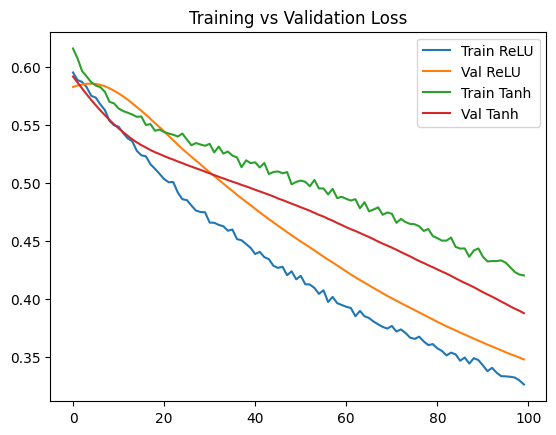


Final Comparison
ReLU Accuracy: 0.9247
Tanh Accuracy: 0.9247


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#data
data = pd.read_csv("Heart_disease - Heart_disease.csv")
X = data.drop("target", axis=1).values
y = data["target"].values

#split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25)

#Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).view(-1, 1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1, 1)

#models&func
def build_model(activation_fn):
    model = nn.Sequential(
        nn.Linear(X_train.shape[1], 32),
        nn.BatchNorm1d(32),
        activation_fn(),
        nn.Dropout(0.3),

        nn.Linear(32, 16),
        nn.BatchNorm1d(16),
        activation_fn(),
        nn.Dropout(0.3),

        nn.Linear(16, 1),
        nn.Sigmoid()
    )
    return model

#training
def train_model(model, lr=0.001, epochs=100):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        print(f"Epoch {epoch+1} | Train: {loss.item():.4f} | Val: {val_loss.item():.4f}")

    return train_losses, val_losses


#Evaluation Function
def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = model(X_test)
        preds = (preds > 0.5).float()
        acc = (preds == y_test).sum() / y_test.shape[0]

    return acc.item()


#ReLU

print("\nReLU")

model_relu = build_model(nn.ReLU)
train_loss_relu, val_loss_relu = train_model(model_relu)

acc_relu = evaluate(model_relu)
print("Test Accuracy (ReLU):", acc_relu)


#Tanh
print("\nTanh")

model_tanh = build_model(nn.Tanh)
train_loss_tanh, val_loss_tanh = train_model(model_tanh)

acc_tanh = evaluate(model_tanh)
print("Test Accuracy (Tanh):", acc_tanh)

#charts
plt.plot(train_loss_relu, label="Train ReLU")
plt.plot(val_loss_relu, label="Val ReLU")

plt.plot(train_loss_tanh, label="Train Tanh")
plt.plot(val_loss_tanh, label="Val Tanh")

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

#accuracy
print("\nFinal Comparison")
print(f"ReLU Accuracy: {acc_relu:.4f}")
print(f"Tanh Accuracy: {acc_tanh:.4f}")

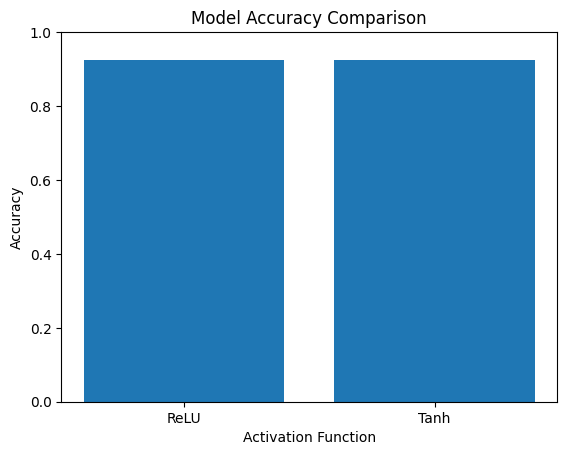

In [5]:
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Activation Function")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()